In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


### How `solve_ivp` works (briefly)

`scipy.integrate.solve_ivp` numerically integrates an initial value problem

$$\dot{y} = f(t, y), \qquad y(t_0) = y_0$$

You give it:
- `fun(t, y)` — a function returning the derivative(s) at time `t`, state `y`.
- `t_span = (t0, tf)` — the interval to integrate over.
- `y0` — the initial condition(s) (always passed as an array/list, even for a single scalar state).
- `t_eval` (optional) — the specific times at which you want the solution reported.

By default it uses an explicit adaptive-step Runge–Kutta method (`RK45`). At each step it estimates the local error and shrinks/grows the step size to keep that error under a tolerance, rather than marching forward in fixed increments — so it takes small steps where the solution changes fast and large steps where it's flat. If you pass `t_eval`, it interpolates the internally-computed solution onto those points.

It returns a result object `sol` with `sol.t` (the times) and `sol.y` (an array of shape `(n_states, n_times)` — one row per state variable), which is what gets plotted below in each example.

## 1. Exponential growth / decay

$$\dot{x} = F x$$

with $F = -1$, $x(0) = 2$.

Exact solution: $x(t) = x_0 e^{Ft}$

**`solve_ivp` here:** `ode1(t, x)` is autonomous (no explicit `t` dependence) and scalar. `solve_ivp` starts from `x0 = [2.0]` and integrates over `t_span = (0, 5)`, using RK45's adaptive stepping — since the dynamics are simple linear decay, it converges to essentially the exact curve with large steps. `t_eval` just controls where the solution is *reported/plotted*, not the internal integration steps.

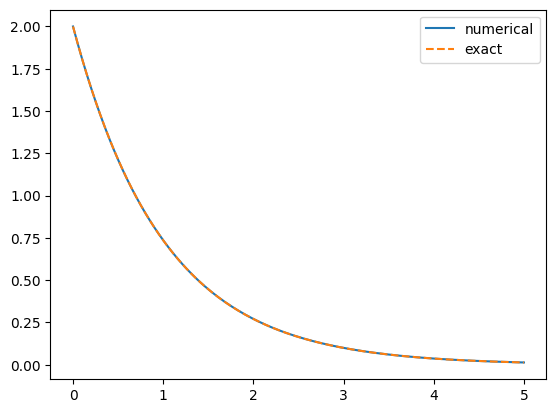

In [3]:
F = -1.0
x0 = [2.0]

def ode1(t, x):
    return F * x

t_span = (0, 5)
t_eval = np.linspace(*t_span, 200)

sol = solve_ivp(ode1, t_span, x0, t_eval=t_eval)

plt.plot(sol.t, sol.y[0], label="numerical")
plt.plot(t_eval, 2*np.exp(F*t_eval), "--", label="exact")
plt.legend()
plt.show()

## 2. Linear ODE with forcing

$$\dot{x} = F x + L\, w(t)$$

with $F = -1$, $L = 2$, $w(t) = \sin(t)$, $x(0) = 0$.

**`solve_ivp` here:** `ode2(t, x)` now depends explicitly on `t` through `w(t) = sin(t)`, making the system non-autonomous. `solve_ivp` evaluates `w(t)` at whatever internal time points RK45's adaptive stepping chooses (not just the 500 points in `t_eval`), so the oscillating forcing term is resolved smoothly regardless of how coarse `t_eval` is.

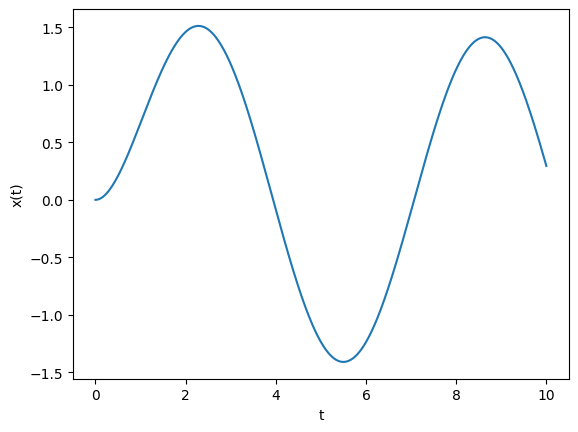

In [4]:
F = -1.0
L = 2.0
x0 = [0.0]

def w(t):
    return np.sin(t)

def ode2(t, x):
    return F * x + L * w(t)

t_span = (0, 10)
t_eval = np.linspace(*t_span, 500)

sol = solve_ivp(ode2, t_span, x0, t_eval=t_eval)

plt.plot(sol.t, sol.y[0])
plt.xlabel("t")
plt.ylabel("x(t)")
plt.show()

## 3. Spring-mass system

$$\ddot{x} + \gamma \dot{x} + \nu^2 x = w(t)$$

or, as a first-order system with $x_1 = x$, $x_2 = \dot{x}$:

$$\dot{x}_1 = x_2$$
$$\dot{x}_2 = -\nu^2 x_1 - \gamma x_2 + w(t)$$

with $\gamma = 1$, $\nu = 2$, $w(t) = 0$, $x_1(0) = 1$, $x_2(0) = 0$.

**`solve_ivp` here:** the second-order ODE is rewritten as the first-order vector system above, so `spring(t, state)` unpacks `state = [x1, x2]` and returns `[dx1, dx2]`. `solve_ivp` handles vector-valued states natively — `y0 = [1.0, 0.0]` — and returns `sol.y` with one row per state variable (`sol.y[0]` = position, `sol.y[1]` = velocity), which is why both can be plotted from the same solve.

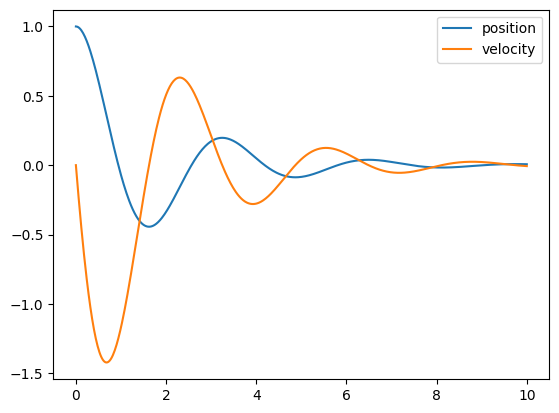

In [5]:
gamma = 1.0
nu = 2.0

def w(t):
    return 0.0

def spring(t, state):
    x1, x2 = state

    dx1 = x2
    dx2 = -nu**2 * x1 - gamma * x2 + w(t)

    return [dx1, dx2]

x0 = [1.0, 0.0]

t_span = (0, 10)
t_eval = np.linspace(*t_span, 500)

sol = solve_ivp(spring, t_span, x0, t_eval=t_eval)

plt.plot(sol.t, sol.y[0], label="position")
plt.plot(sol.t, sol.y[1], label="velocity")
plt.legend()
plt.show()

## 4. Mean-reverting ODE

$$\dot{x} = \theta_1 (\theta_2 - x)$$

with $\theta_1 = 1.5$, $\theta_2 = 5$, $x(0) = 0$.

Exact solution: $x(t) = \theta_2 + (x_0 - \theta_2) e^{-\theta_1 t}$

**`solve_ivp` here:** `ode4(t, x)` is a simple linear relaxation toward the equilibrium `theta2`, plotted with a dashed line via `plt.axhline`. Since the dynamics are smooth and non-stiff, RK45's adaptive steps grow as `x` approaches equilibrium and the derivative shrinks. The second cell recomputes the exact solution directly at the `t_eval` points and overlays it on `sol.y[0]` to confirm the numerical and analytic solutions agree.

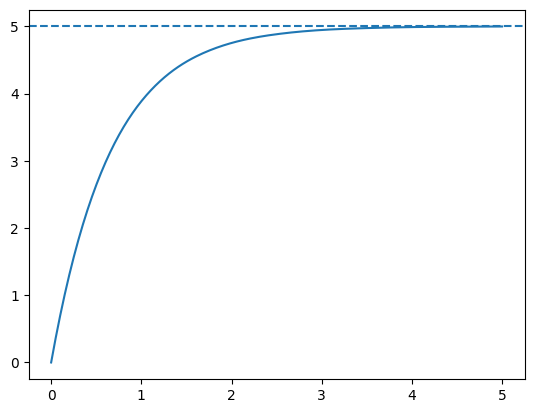

In [6]:
theta1 = 1.5
theta2 = 5.0
x0 = [0.0]

def ode4(t, x):
    return theta1 * (theta2 - x)

t_span = (0, 5)
t_eval = np.linspace(*t_span, 200)

sol = solve_ivp(ode4, t_span, x0, t_eval=t_eval)

plt.plot(sol.t, sol.y[0])
plt.axhline(theta2, linestyle="--")
plt.show()

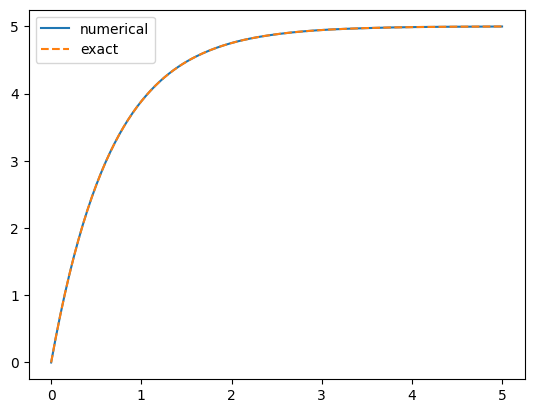

In [7]:
exact = theta2 + (x0[0] - theta2) * np.exp(-theta1 * t_eval)

plt.plot(sol.t, sol.y[0], label="numerical")
plt.plot(t_eval, exact, "--", label="exact")
plt.legend()
plt.show()

## 5. Pure exponential growth

$$\dot{x} = x$$

with $x(0) = 1$.

Exact solution: $x(t) = x_0 e^{t}$

**`solve_ivp` here:** same mechanics as example 1, but with unstable (growing) dynamics instead of decay. As `x(t)` grows over `t_span = (0, 1)`, so does its derivative `x` itself — RK45 shrinks its adaptive step size to keep the local error estimate within tolerance as the solution steepens, rather than losing accuracy.

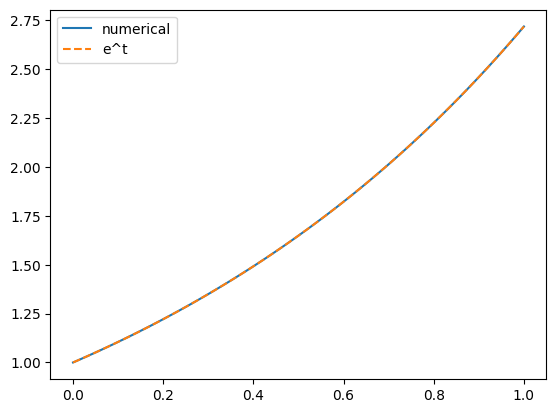

In [8]:
def ode5(t, x):
    return x

x0 = [1.0]

t_span = (0, 1)
t_eval = np.linspace(*t_span, 100)

sol = solve_ivp(ode5, t_span, x0, t_eval=t_eval)

plt.plot(sol.t, sol.y[0], label="numerical")
plt.plot(t_eval, np.exp(t_eval), "--", label="e^t")
plt.legend()
plt.show()

## 6. Nonlinear ODE

$$\dot{y} = y^2 - 1$$

with $y(0) = 0$.

Exact solution: $y(t) = -\tanh(t)$

**`solve_ivp` here:** `ode6(t, y) = y**2 - 1` is nonlinear, with equilibria at $y = \pm 1$. Starting at $y(0)=0$, between the two equilibria, the trajectory decays toward the stable one at $y=-1$. `solve_ivp` doesn't need or use the closed-form solution — it just integrates `y**2 - 1` step by step — but since this particular ODE happens to be solvable analytically, the second cell overlays $-\tanh(t)$ as a sanity check on the numerical result.

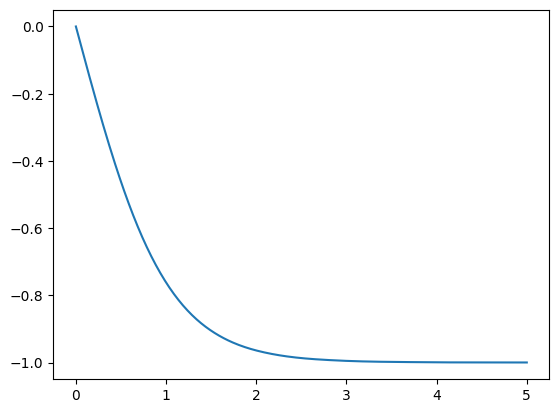

In [9]:
def ode6(t, y):
    return y**2 - 1

y0 = [0.0]

t_span = (0, 5)
t_eval = np.linspace(*t_span, 300)

sol = solve_ivp(ode6, t_span, y0, t_eval=t_eval)

plt.plot(sol.t, sol.y[0])
plt.show()

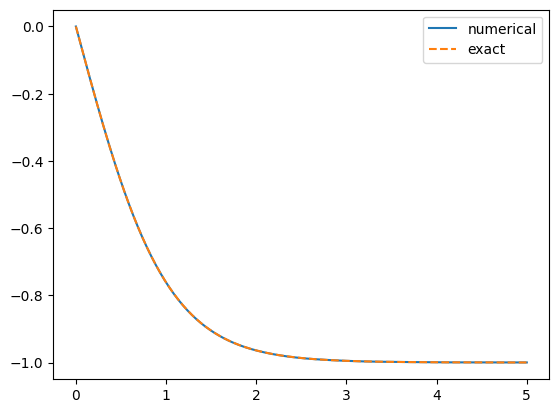

In [10]:
plt.plot(sol.t, sol.y[0], label="numerical")
plt.plot(t_eval, -np.tanh(t_eval), "--", label="exact")
plt.legend()
plt.show()

## How solve ivp works

In [ ]:
import numpy as np

def simple_solve_ivp(f, t_span, y0, h=0.1, tol=1e-6):
    t0, tf = t_span
    t = t0
    y = np.array(y0, dtype=float)

    ts = [t]
    ys = [y.copy()]

    while t < tf:

        # Don't step past tf
        h = min(h, tf - t)

        # Runge-Kutta slope evaluations
        k1 = f(t, y)

        k2 = f(
            t + h/4,
            y + h*(1/4)*k1
        )

        k3 = f(
            t + 3*h/8,
            y + h*(3/32*k1 + 9/32*k2)
        )

        k4 = f(
            t + 12*h/13,
            y + h*(1932/2197*k1
                   - 7200/2197*k2
                   + 7296/2197*k3)
        )

        k5 = f(
            t + h,
            y + h*(439/216*k1
                   - 8*k2
                   + 3680/513*k3
                   - 845/4104*k4)
        )

        k6 = f(
            t + h/2,
            y + h*(-8/27*k1
                   + 2*k2
                   - 3544/2565*k3
                   + 1859/4104*k4
                   - 11/40*k5)
        )

        # 4th-order estimate
        y4 = y + h*(
            25/216*k1
            + 1408/2565*k3
            + 2197/4104*k4
            - 1/5*k5
        )

        # 5th-order estimate
        y5 = y + h*(
            16/135*k1
            + 6656/12825*k3
            + 28561/56430*k4
            - 9/50*k5
            + 2/55*k6
        )

        # Estimate error
        error = np.max(np.abs(y5 - y4))

        if error < tol:
            # Accept step
            t += h
            y = y5

            ts.append(t)
            ys.append(y.copy())

        # Adjust step size
        if error == 0:
            h *= 2
        else:
            h *= 0.9 * (tol / error)**0.2

    return np.array(ts), np.array(ys)